In [1]:
from google.colab import files

uploaded = files.upload()

Saving Titanic-Dataset.csv to Titanic-Dataset.csv


First 5 Rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN

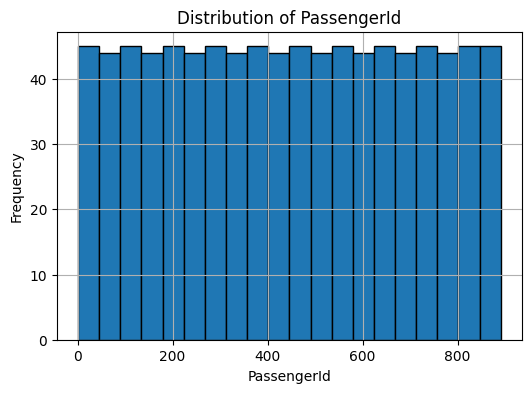

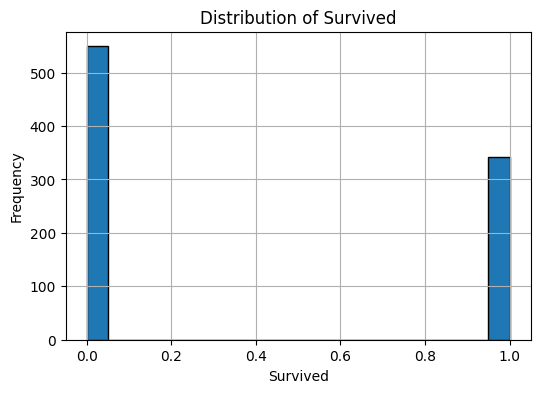

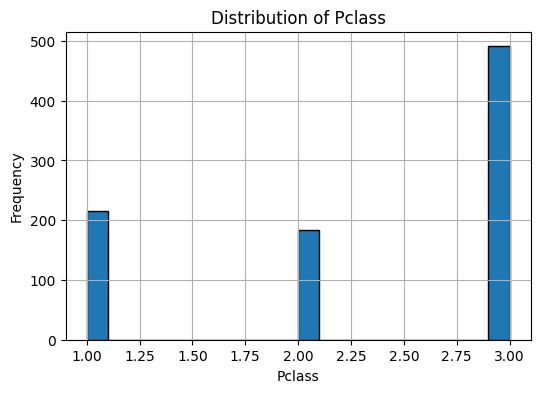

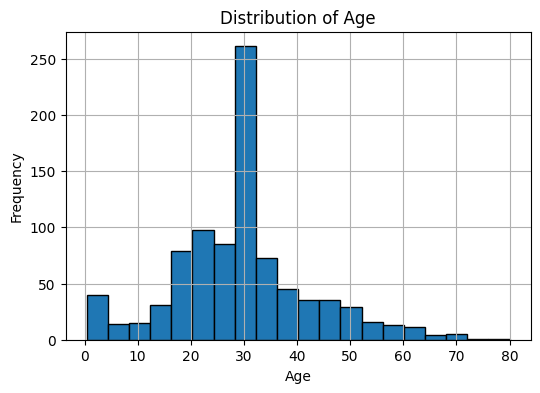

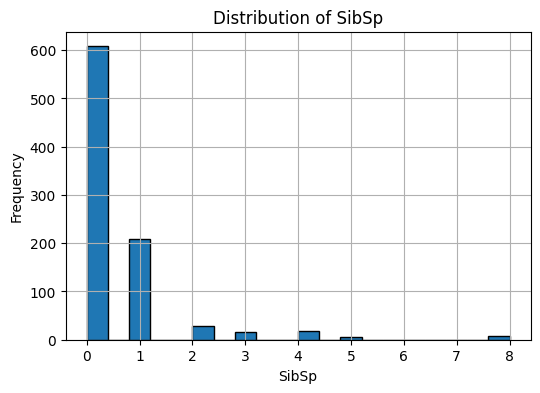

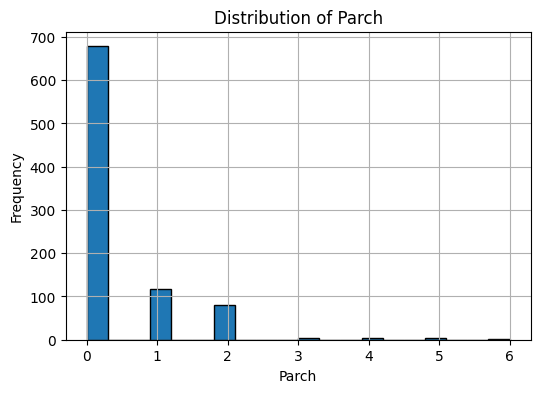

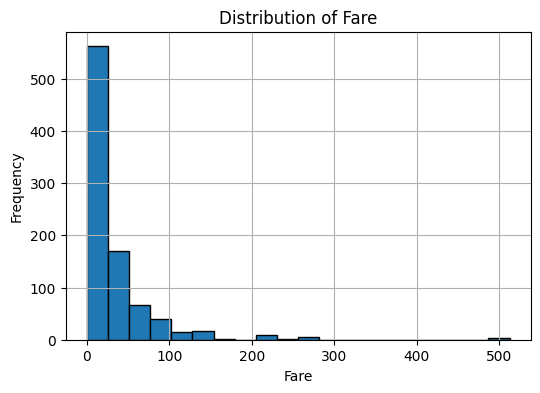


Correlation Matrix:
             PassengerId  Survived    Pclass       Age     SibSp     Parch  \
PassengerId     1.000000 -0.005007 -0.035144  0.033207 -0.057527 -0.001652   
Survived       -0.005007  1.000000 -0.338481 -0.069809 -0.035322  0.081629   
Pclass         -0.035144 -0.338481  1.000000 -0.331339  0.083081  0.018443   
Age             0.033207 -0.069809 -0.331339  1.000000 -0.232625 -0.179191   
SibSp          -0.057527 -0.035322  0.083081 -0.232625  1.000000  0.414838   
Parch          -0.001652  0.081629  0.018443 -0.179191  0.414838  1.000000   
Fare            0.012658  0.257307 -0.549500  0.091566  0.159651  0.216225   

                 Fare  
PassengerId  0.012658  
Survived     0.257307  
Pclass      -0.549500  
Age          0.091566  
SibSp        0.159651  
Parch        0.216225  
Fare         1.000000  


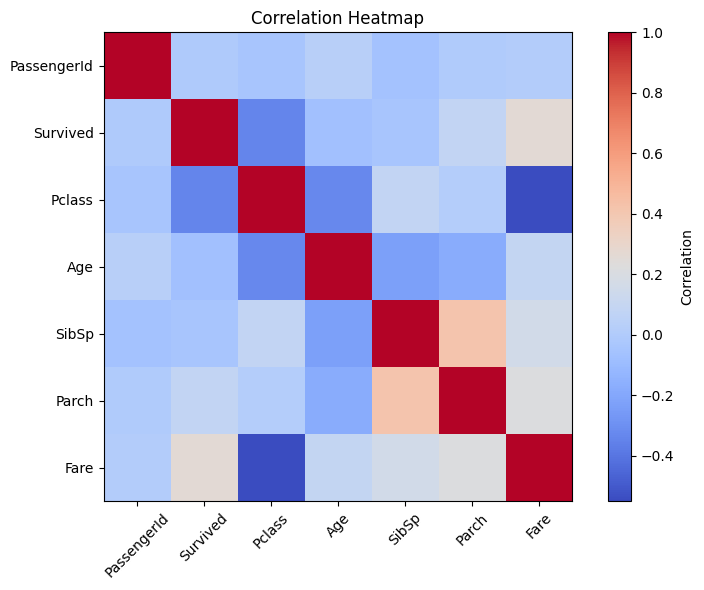

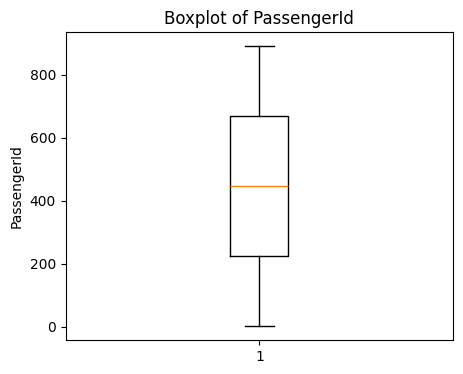

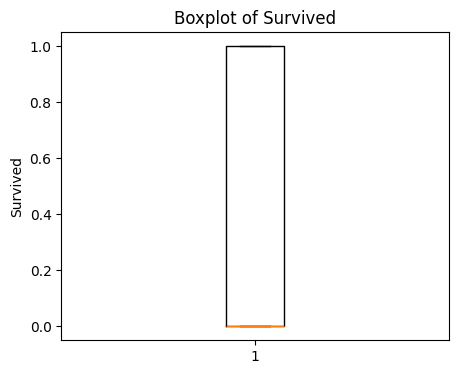

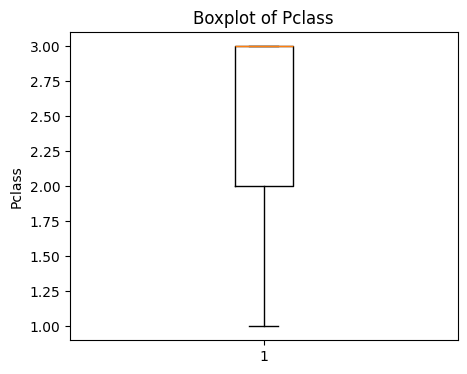

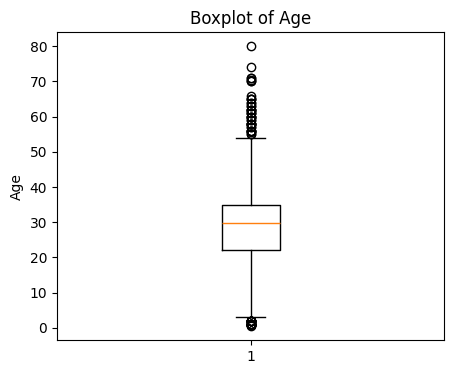

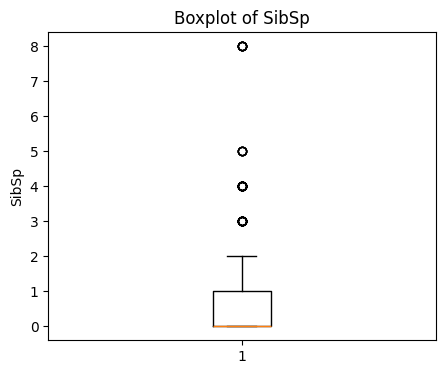

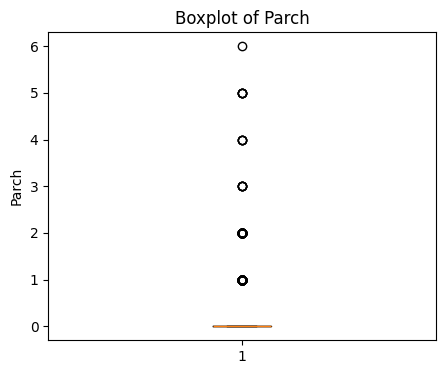

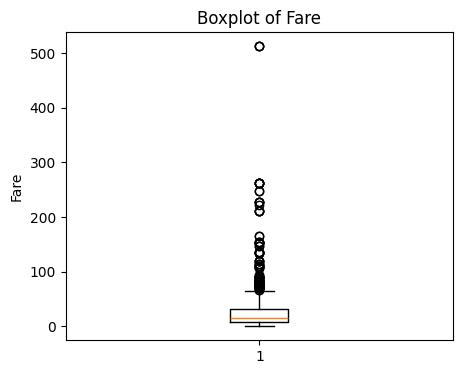

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load Dataset
df = pd.read_csv("Titanic-Dataset.csv")

print("First 5 Rows:")
print(df.head())

print("\nDataset Information:")
print(df.info())


# 2. Data Cleaning

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Fill missing numeric values with mean
numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

# Fill missing categorical values with mode
categorical_cols = df.select_dtypes(exclude=np.number).columns
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Remove duplicate rows
df.drop_duplicates(inplace=True)

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())


# 3. Summary Statistics
print("\nSummary Statistics:")
print(df.describe())


# 4. Distribution Plots (Histograms)
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    plt.hist(df[col], bins=20, edgecolor='black')
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.show()

# 5. Correlation Matrix
correlation = df[numeric_cols].corr()

print("\nCorrelation Matrix:")
print(correlation)


# 6. Correlation Heatmap using Matplotlib
plt.figure(figsize=(8,6))
plt.imshow(correlation, cmap='coolwarm', interpolation='nearest')

plt.colorbar(label="Correlation")

plt.xticks(range(len(correlation.columns)),
           correlation.columns,
           rotation=45)

plt.yticks(range(len(correlation.columns)),
           correlation.columns)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


# 7. Boxplots for Outlier Detection
for col in numeric_cols:
    plt.figure(figsize=(5,4))
    plt.boxplot(df[col], vert=True)
    plt.title(f"Boxplot of {col}")
    plt.ylabel(col)
    plt.show()